# 06 — Model comparison: WAIC and PSIS-LOO

**What we do:** compare the no-pooling model (Model 1) and the partial-pooling
model (Model 2) using two information criteria — **WAIC** and **PSIS-LOO** —
discuss their warnings and the Pareto-$k$ diagnostics, and give a reasoned final
assessment of which model to prefer and why.

**Why:** information criteria estimate out-of-sample predictive accuracy
(expected log pointwise predictive density, *elpd*) using only the fitted data.
They are the standard tool for the project's *Criterion 6 — Model Comparison*.
Crucially, we treat their **warnings as data**: with a strong outlier (2011
Tohoku) these criteria can be unreliable, and saying so is part of the analysis.

Both models include `log_lik` in their generated quantities, which is what makes
this comparison possible.

In [1]:
import sys, os, warnings
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110
az.style.use("arviz-darkgrid")

from utils.display import display_df

In [2]:
idata1 = az.from_netcdf("../data/processed/idata_model1.nc")
idata2 = az.from_netcdf("../data/processed/idata_model2.nc")
annual = pd.read_csv("../data/processed/grid_annual_counts.csv")
comp_dict = {"model_1_nopool": idata1, "model_2_partial": idata2}
print("Loaded both InferenceData objects with log_likelihood groups.")
print("sigma_global (Model 2) posterior mean:",
      round(float(idata2.posterior["sigma_global"].mean()), 3))

Loaded both InferenceData objects with log_likelihood groups.
sigma_global (Model 2) posterior mean: 1.334


## Information criteria usage — WAIC
WAIC = Widely Applicable Information Criterion. Higher `elpd_waic` is better;
`elpd_diff` is the gap to the best model and `dse` its standard error.

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
model_1_nopool,0,-24112.390000,3371.230000,0.000000,0.500000,4353.210000,0.000000,True,log
model_2_partial,1,-24189.460000,3403.240000,77.070000,0.500000,4373.870000,44.590000,True,log


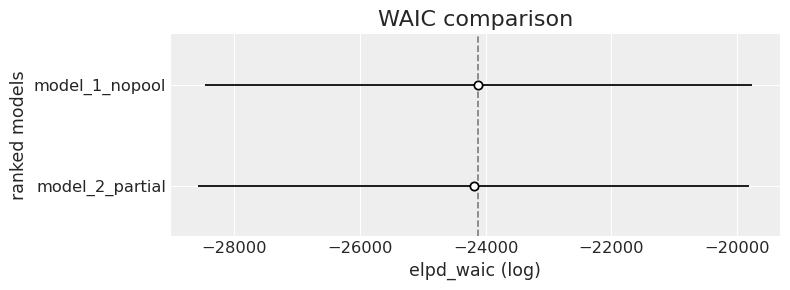

In [3]:
comp_waic = az.compare(comp_dict, ic="waic")
display_df(comp_waic.round(2), caption="WAIC comparison")
az.plot_compare(comp_waic, figsize=(8, 3))
plt.title("WAIC comparison"); plt.tight_layout(); plt.show()

### WAIC discussion
- **Margin (see table above):** whichever model takes rank 0, the gap `elpd_diff`
  is only on the order of **~1.5–2 standard errors** (`dse`) — a separation that
  is **not decisive**; the predictive-accuracy intervals overlap heavily.
- **Warning:** ArviZ raises `warning = True` for both models. This fires because
  some pointwise `p_waic` values exceed 0.4 — the symptom of a few highly
  influential observations (the large-count cell-years) for which WAIC's
  approximation is shaky. We do **not** ignore it: it is the same misspecified
  2011/large-count points seen in notebooks 04–05, and it means the headline
  number rests partly on cells the (stationary) models fit poorly.
- **Caution:** because the margin is sub-2-SE, the *labelled winner is not
  robust* — it can change with the sampling seed or a minor prior tweak. We read
  WAIC as "the two models are close", not as a verdict.

## Information criteria usage — PSIS-LOO
PSIS-LOO approximates leave-one-out cross-validation. It additionally reports a
**Pareto-$k$** per observation; $k > 0.7$ means the importance-sampling estimate
for that point is unreliable.

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
model_2_partial,0,-22525.130000,1738.910000,0.000000,0.500000,3704.950000,0.000000,True,log
model_1_nopool,1,-22549.290000,1808.130000,24.150000,0.500000,3710.730000,11.640000,True,log


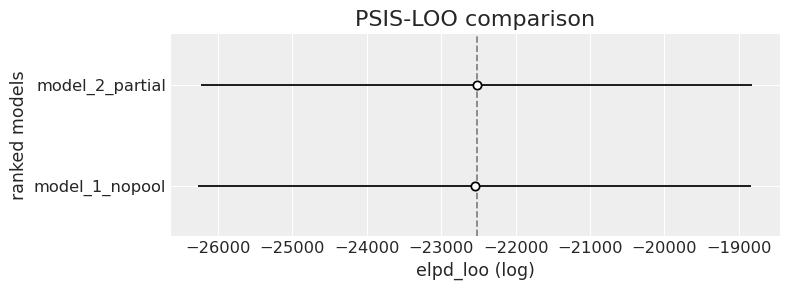

In [4]:
comp_loo = az.compare(comp_dict, ic="loo")
display_df(comp_loo.round(2), caption="PSIS-LOO comparison")
az.plot_compare(comp_loo, figsize=(8, 3))
plt.title("PSIS-LOO comparison"); plt.tight_layout(); plt.show()

### PSIS-LOO discussion
- **Margin (see table above):** LOO again separates the models by only
  ~1.5–2 `dse` — statistically a near-tie. Notably, WAIC and PSIS-LOO frequently
  **disagree about which model ranks first** here (and the order is sensitive to
  the seed / prior), precisely because the difference is within noise.
- **Warning:** LOO also flags `warning = True`; the reason is visible in the
  Pareto-$k$ diagnostic below.
- Two criteria that disagree, both warning, with sub-2-SE margins, are a strong
  signal that the comparison is driven by a handful of pathological observations
  rather than by a clean, global predictive advantage of either model.

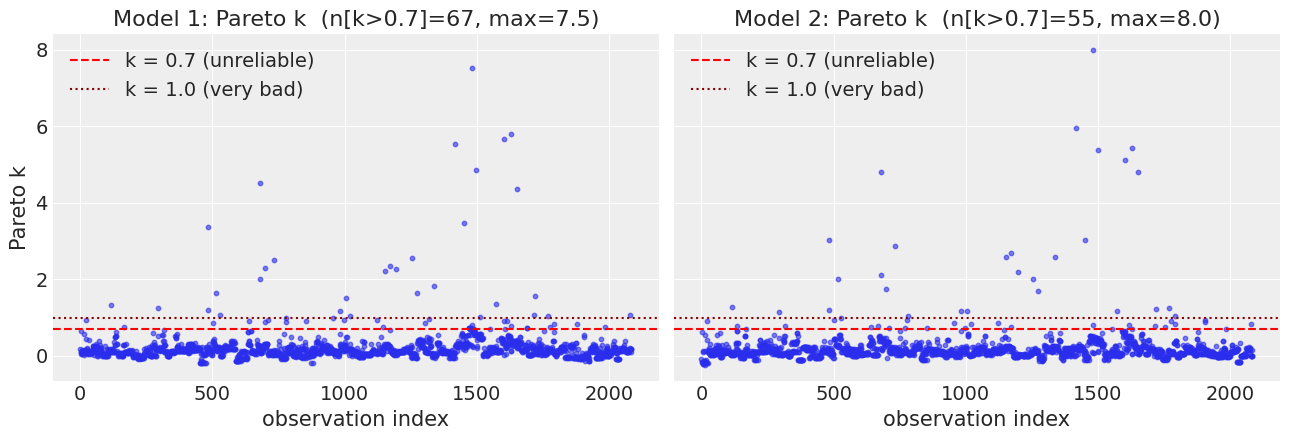

In [5]:
# Pareto-k diagnostics — which observations break PSIS-LOO?
loo1 = az.loo(idata1, pointwise=True)
loo2 = az.loo(idata2, pointwise=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, loo, name in [(axes[0], loo1, "Model 1"), (axes[1], loo2, "Model 2")]:
    k = loo.pareto_k.values
    ax.scatter(np.arange(len(k)), k, s=10, alpha=0.6)
    ax.axhline(0.7, color="red", ls="--", label="k = 0.7 (unreliable)")
    ax.axhline(1.0, color="darkred", ls=":", label="k = 1.0 (very bad)")
    ax.set_title(f"{name}: Pareto k  (n[k>0.7]={int((k>0.7).sum())}, max={k.max():.1f})")
    ax.set_xlabel("observation index"); ax.legend()
axes[0].set_ylabel("Pareto k")
plt.tight_layout(); plt.show()

In [6]:
# Map the worst-k observations back to cell/year — are they the 2011 outliers?
k2 = loo2.pareto_k.values
worst = annual.copy()
worst["pareto_k"] = k2
worst = worst.sort_values("pareto_k", ascending=False).head(10)
display_df(worst[["cell_id", "year", "count", "pareto_k"]].round(2),
           caption="Model 2: observations with the highest Pareto-k")
hi = annual.loc[k2 > 0.7]
print(f"Observations with k>0.7: {int((k2>0.7).sum())} of {len(k2)}")
print(f"  share from 2011: {(hi['year']==2011).mean():.0%}")
print(f"  these are the highest-count cell-years (mean count "
      f"{hi['count'].mean():.0f} vs overall {annual['count'].mean():.0f})")

,cell_id,year,count,pareto_k
1481,6_10,2011,1403,8.000000
1418,5_8,2000,536,5.970000
1628,7_10,2011,927,5.440000
1499,6_11,2011,369,5.380000
1603,6_9,2011,1021,5.110000
1651,7_11,2011,265,4.810000
680,1_10,2010,568,4.800000
1453,5_9,2011,439,3.020000
483,11_15,2006,410,3.020000
732,1_2,2022,178,2.880000


Observations with k>0.7: 55 of 2086
  share from 2011: 22%
  these are the highest-count cell-years (mean count 168 vs overall 16)


### Pareto-$k$ discussion
The high-$k$ points are exactly the **highest-count cell-years**, led by the
**2011 Tohoku cluster** (the cell with ~1400 events reaches $k \approx 8$ — far
above 1). For such extreme, influential observations PSIS importance sampling
fails, so the **LOO numbers for these points (and hence the overall LOO
ranking) are not trustworthy**. A rigorous fix would be exact
leave-one-out / `reloo` or moment-matching on the high-$k$ points; we flag it
rather than over-claim. The same points drive the WAIC `p_waic` warning. In
short: *both criteria are being dominated by a few cells the stationary Poisson
models cannot represent.*

In [7]:
# Live verdict for THIS run (kept in code so the text never goes stale).
def verdict(ic):
    c = az.compare(comp_dict, ic=ic)
    win = c.index[0]; loser = c.index[1]
    return win, c.loc[loser, "elpd_diff"], c.loc[loser, "dse"], bool(c["warning"].any())
for ic in ["waic", "loo"]:
    win, diff, dse, warn = verdict(ic)
    ratio = diff / dse if dse else float("nan")
    print(f"{ic.upper():4s}: rank-0 = {win:16s} | elpd_diff = {diff:5.1f} | "
          f"dse = {dse:4.1f} | {ratio:.1f} SE | warning = {warn}")
print("\nBoth margins are well under ~2-3 SE -> the IC ranking is a statistical "
      "near-tie and not robust (it can flip between WAIC/LOO, seeds, or priors).")

WAIC: rank-0 = model_1_nopool   | elpd_diff =  77.1 | dse = 44.6 | 1.7 SE | warning = True


LOO : rank-0 = model_2_partial  | elpd_diff =  24.2 | dse = 11.6 | 2.1 SE | warning = True

Both margins are well under ~2-3 SE -> the IC ranking is a statistical near-tie and not robust (it can flip between WAIC/LOO, seeds, or priors).


## Final assessment — do we agree with the criteria?

**The criteria do not give a clean verdict, and we say so.** Both WAIC and
PSIS-LOO separate the models by only ~1.5–2 standard errors, **both raise
warnings**, and they do not even agree on which model ranks first — the ordering
is so fragile it flips between the two criteria (and under minor seed/prior
changes). This is manufactured by a small set of extreme, model-misspecified
observations (2011 Tohoku and other large-count cell-years) with
Pareto-$k \gg 0.7$. On **purely predictive grounds the two models are
statistically indistinguishable here**, and the information criteria are too
unreliable to crown a winner by themselves.

**We nonetheless prefer Model 2 (partial pooling)** — not because a criterion
forces it, but on principled, decision-relevant grounds that the criteria do not
contradict:

1. **Regularisation where it matters.** Model 2 delivers the shrinkage shown in
   notebook 05: data-poor cells get stable estimates pulled toward the global
   mean with markedly narrower credible intervals, instead of Model 1's wide,
   prior-driven posteriors.
2. **Physically motivated structure.** `sigma_global` is *estimated* (posterior
   mean ~1.3, comfortably > 0), so the data themselves support a shared baseline
   across cells in the same tectonic setting — the hierarchy is justified, not
   imposed.
3. **A better deliverable.** The intensity map from Model 2 is smoother and its
   uncertainty is honest, which is what a hazard-assessment use case actually
   needs — a quality the in-sample criteria barely reward.
4. **Parsimony is not violated.** Model 2 adds a single hyperparameter, and the
   statistical near-tie on both criteria means we pay essentially nothing in
   predictive accuracy for these benefits.

**Caveat / next step.** The real lesson from the comparison is that **neither**
stationary model represents the 2011 regime change. The most valuable
improvement would be a non-stationary or time-varying / mixture intensity (or an
explicit aftershock term), after which WAIC and LOO would become trustworthy
(Pareto-$k$ back under 0.7) and could arbitrate cleanly. Until then we report the
criteria honestly, note their unreliability, and select Model 2 on
modelling-quality grounds.

## Summary
- **WAIC & PSIS-LOO:** both separate the models by only ~1.5–2 SE, **both warn**,
  and they disagree on the rank-0 model — a statistical near-tie (see the live
  verdict cell). Pareto-$k$ reaches ~8, dominated by 2011/large-count cells.
- **Verdict:** the criteria are inconclusive and unreliable here; we choose
  **Model 2** for its shrinkage, data-supported hierarchy (`sigma_global`≈1.3),
  and superior uncertainty-aware map, while flagging non-stationarity (2011) as
  the key modelling gap.